In [100]:
import numpy as np
import pandas as pd
from scipy import ndimage, misc
from scipy.optimize import curve_fit
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import axes3d
import matplotlib.backends.backend_pdf
from lmfit import Model
%matplotlib inline


In [101]:
arrayshape = pd.read_csv('imagearrayJENSA.csv')
#arrayshape.head(1)


In [102]:
#size_0 is number of columns and size_1 is number of rows
size_x = int(np.genfromtxt('imagearrayJENSAsize0.csv', usecols=(1,)))
size_y = int(np.genfromtxt('imagearrayJENSAsize1.csv', usecols=(1,)))

#skipping PV name and importing array
header_size = 2
size = int(np.genfromtxt('imagearrayJENSA.csv', usecols=(1,)))
image_array = np.genfromtxt('imagearrayJENSA.csv', usecols= range(header_size,  header_size + size_x*size_y))


In [103]:
print(size_x, size_y)
print(image_array.shape
     )

704 480
(337920,)


In [104]:
#reshaping into 2D array
image_array.shape = (size_y, size_x)
print(image_array.shape)

(480, 704)


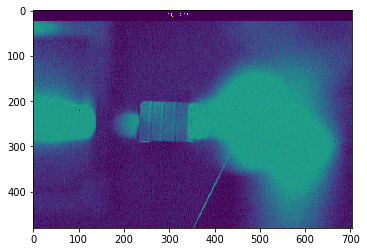

In [105]:
plt.imshow(image_array)

In [106]:
 def double_gaussian( x, c1, mu1,offset):
        sigma1=2.6
        sigma2=5.6
        res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
              + c1*1.18245 * np.exp( - (x - (mu1+4.9))**2.0 / (2.0 * sigma2**2.0) ) + offset
        return res

In [107]:
class Image:    
    def __init__(self, image):
        self.raw = image
        self.shape= image.shape
        self.x_size= image.shape[1]
        self.y_size= image.shape[0]
        self.subtracted_data= image                                  #np.array([[0 for x in range(self.x_size)] for y in range(self.y_size)])
        self.profile_x= [0 in range (self.x_size)]
        self.profile_y= [0 in range (self.y_size)]
        self.offset_x= 0 
        self.offset_y= 0

    def subtract_bg(self,bg):
        print("Subtracting background...")
        if (bg.shape == self.shape): 
            for i in range(self.y_size):
                for j in range (self.x_size):
                    if ((self.raw[i][j]>bg[i][j]).all() and (bg[i][j]>=0).all() and (self.raw[i][j]>=0).all()):
                        self.subtracted_data[i][j]= self.raw[i][j]-bg[i][j]
                    elif (bg[i][j]<0):
                        self.subtracted_data[i][j]= 0
            return self.subtracted_data
        else:
            print("Error: Background image size :",bg.shape," does not match data size ",self.shape,".")
            
    def get_profile(self):
        print("Getting y-axis profile...")
        #PROFILE IN Y
        for i in range(self.y_size): #loop over all y
            sum=0
            for j in range(self.x_size): #loop over all x for each y: gives one number
                sum=sum + self.subtracted_data[i][j]
            self.profile_y.append(sum)
        self.offset_y= np.mean(self.profile_y[1:3])
        self.profile_y=self.profile_y[1:]                                              #- self.offset_y      
     
        #PROFILE IN X
        print("Getting x-axis profile...")
        for i in range(self.x_size): #loop over all x
            sum=0
            for j in range(self.y_size): #loop over all y for each x: gives one number
                sum=sum + self.subtracted_data[j][i]
            self.profile_x.append(sum)
        self.offset_x=np.mean(self.profile_x[1:3])
        self.profile_x=self.profile_x[1:]                                               #-self.offset_x

def findMedian(profile):
    sum_total=sum(profile)
    median=0
    sigp=0
    sign=0
    for i in range(len(profile)):
        sumInt=sum(profile[0:i])
        frac=sumInt/sum_total
        if (frac>0.15 and frac<0.17):
            sign=i
        elif (frac>0.48 and frac<0.52):
            median=i
        elif (frac>0.45 and frac<0.54):
            median=i
        elif (frac>0.41 and frac<0.58):
            median=i
        elif (frac>0.83 and frac<0.85):
            sigp=i
    if (median==0):
        print("Error when finding median. Check im_reduction ln 62.")
    return  median, sigp, sign

In [108]:
image=Image(image_array)
#image.subtract_bg(bg)
image.get_profile()

Getting y-axis profile...
Getting x-axis profile...


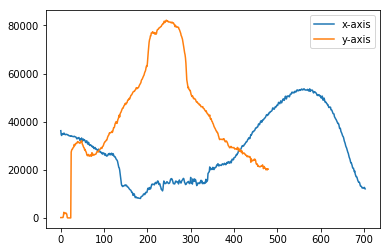

In [109]:
plt.plot(image.profile_x, label="x-axis")
plt.plot(image.profile_y, label="y-axis")
plt.legend()

In [110]:
 ############################### PROFILE INTEGRATION AND GAUSSIAN PLOT ####################################### 

gmod = Model(double_gaussian)
result = gmod.fit(profile,x=x, c1=5000000, mu1=300,offset=2100000)
#print(result.fit_report())
x1.append(result.params['mu1'].value)
stderr1.append(result.params['mu1'].stderr)

dely = result.eval_uncertainty(sigma=3)
ax=plt.axes()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.text(288,4800000, """
: 
stderr1 : %.2f
x2 : %.2f""" %(result.params['mu1'].value , result.params['mu1'].stderr,result.params['mu1'].value+4.9),
        fontsize=11, horizontalalignment='right',
        verticalalignment='top',  color="black")

plt.fill_between(x, result.best_fit-dely, result.best_fit+dely, color="#ABABAB",label='3sig error')
plt.plot(x, profile,         'bo', label='data')
plt.plot(x, result.best_fit, 'b-',label='fit')

plt.xlabel('X-position (pixels)')
plt.ylabel('Counts (arb)')
plt.title('Tune %d Double Gaussian Fit' %(nn[cnt]))
plt.legend(loc="upper right")
# change font size
plot_num += 1
pdf.savefig(fig)
cnt += 1

gaussian=result.best_fit-result.params['offset'].value 
partialI=0
sumInt=0
sumP=[ 0 in range (55)]
#for i in range(630):
#   partialI=partialI+gaussian[i]
#  sumP.append(partialI/sumInt*100)


for i in range(55):
    sumInt=sumInt+gaussian[i]

    #sumInt=sumInt-2100000*630
    #profile[:]=[x-2100000 for x in profile]

for i in range(55):
    partialI=partialI+gaussian[i]
    sumP.append(partialI/sumInt)
    if ((partialI/sumInt)*100>45 and (partialI/sumInt*100)<55):
        print("Pixel ",i+280," is at ",partialI/sumInt*100,"% of dat

SyntaxError: EOL while scanning string literal (<ipython-input-110-fd5d46fb59b7>, line 52)

In [73]:
centroid_05=[309,308,308.5,306.5,306.5,306.5,305,304.5,304,304,302,301.5,300,299.5,298.5,297.5,297,296.5,295.5,295]
centroid_05_=[309,308,308.5,306.5,306.5,305,304.5,304,304,302,301.5,301,300,299.5,298.5,297.5,297,296.5,295.5,295]


In [50]:
print(x1,stderr1)

[True, 306.39719746420019, 305.86814167404304, 306.03549187239628, 304.2251683464342, 304.19049042814612, 302.53589597162983, 302.31433695354201, 301.8953015241824, 301.44594582024325, 299.67251388818875, 299.3108406428284, 298.77911083137928, 297.84061084489326, 296.97407716548145, 296.1057788316437, 295.13158944387612, 294.79190787223905, 294.22227501085871, 293.14685112350446, 292.92397163081307] [True, 0.095733133858977595, 0.087488808154283046, 0.092757638714504584, 0.099608333731256743, 0.097571366986687044, 0.089053520541766601, 0.083914271491833767, 0.077193963256203119, 0.079402975074007121, 0.09618030661908733, 0.10222070915892392, 0.11066734953488849, 0.10565632901883586, 0.089034151873872994, 0.1094106161473825, 0.10824897766940371, 0.10767111227579634, 0.099418334113674525, 0.097324171204549628, 0.1023339638720447]


In [73]:
x1=[306.39719746420019, 305.86814167404304, 306.03549187239628, 304.2251683464342, 304.19049042814612, 302.53589597162983, 302.31433695354201, 301.8953015241824, 301.44594582024325, 299.67251388818875, 299.3108406428284, 298.77911083137928, 297.84061084489326, 296.97407716548145, 296.1057788316437, 295.13158944387612, 294.79190787223905, 294.22227501085871, 293.14685112350446, 292.92397163081307]
stderr1=[0.095733133858977595, 0.087488808154283046, 0.092757638714504584, 0.099608333731256743, 0.097571366986687044, 0.089053520541766601, 0.083914271491833767, 0.077193963256203119, 0.079402975074007121, 0.09618030661908733, 0.10222070915892392, 0.11066734953488849, 0.10565632901883586, 0.089034151873872994, 0.1094106161473825, 0.10824897766940371, 0.10767111227579634, 0.099418334113674525, 0.097324171204549628, 0.1023339638720447]
print(len(stderr1))
stderr_c=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
mid_c=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
for i in range(len(x1)):
    stderr_c[i]=np.sqrt((3*stderr1[i])**2+(0.5)**2)
    mid_c[i]=(2*x1[i]+4.9)/2
print(x1,mid_c,stderr_c)

20
[306.3971974642002, 305.86814167404304, 306.0354918723963, 304.2251683464342, 304.1904904281461, 302.5358959716298, 302.314336953542, 301.8953015241824, 301.44594582024325, 299.67251388818875, 299.3108406428284, 298.7791108313793, 297.84061084489326, 296.97407716548145, 296.1057788316437, 295.1315894438761, 294.79190787223905, 294.2222750108587, 293.14685112350446, 292.92397163081307] [308.8471974642002, 308.31814167404303, 308.48549187239627, 306.6751683464342, 306.6404904281461, 304.9858959716298, 304.764336953542, 304.3453015241824, 303.89594582024324, 302.12251388818873, 301.7608406428284, 301.2291108313793, 300.29061084489325, 299.42407716548144, 298.5557788316437, 297.5815894438761, 297.24190787223904, 296.6722750108587, 295.59685112350445, 295.37397163081306] [0.57661381900380115, 0.56470224363846167, 0.57222007642079031, 0.58249152898429069, 0.57938031110908217, 0.56689925532491714, 0.55979857506075048, 0.55102647093293111, 0.55384428502552097, 0.57728317352238401, 0.5865506

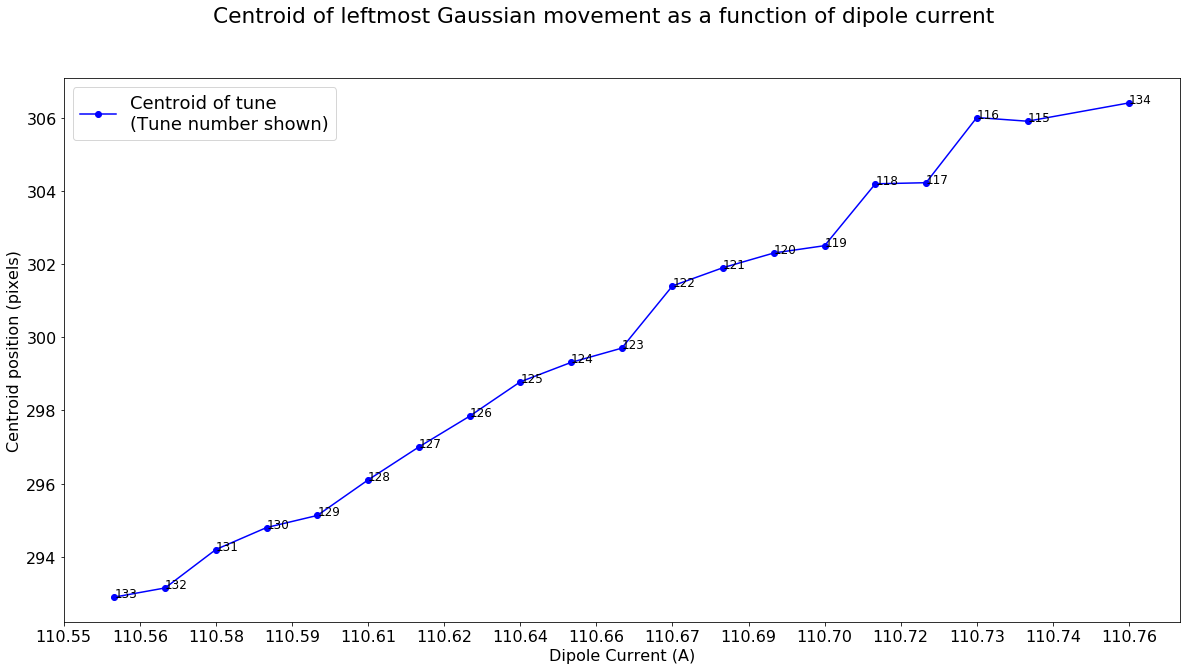

In [75]:
centroid=[306.4,305.9,306,304.22,304.19,302.5,302.3,301.9,301.4,299.7,299.31,298.78,297.84,297,296.1,295.13,294.8,294.2,293.15
,292.9]
y=[1,1,1,1,1,1,1,1,1,1,1]
n=[134,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133]
current=[ 110.76 ,110.74 , 110.73,  110.72 , 110.71 , 110.7 ,  \
         110.69  ,110.68 ,110.67 , 110.66 ,110.65,110.64,110.63,110.62,110.61,110.60,110.59,110.58,110.57 , 110.56]




ax = plt.axes()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.015))

for i, txt in enumerate(n):
    plt.annotate(txt, (current[i], centroid[i]), fontsize=12)
    
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%0.2f'))
plt.plot(current,centroid, c='b', marker='o', label='Centroid of tune \n(Tune number shown)' )

plt.rcParams['figure.figsize'] = 20,10


plt.rcParams.update({'font.size': 18})
plt.suptitle('Centroid of leftmost Gaussian movement as a function of dipole current')
plt.xlabel('Dipole Current (A)')
plt.ylabel('Centroid position (pixels)')
plt.legend(loc="upper left")
plt.rcParams.update({'font.size': 16})
plt.rcParams['figure.figsize'] = 20,10
#plt.savefig("BCMctr_Dcurrent.pdf")
plt.show()
